# Lab 3.1 — Prompt Engineering: Zero-Shot, Few-Shot, and Chain-of-Thought
### Module 4: Large Language Models | Chitkara University B-Tech AI Specialization
---
**Duration:** 90 minutes | **Mode:** Individual | **Day 3 — Wednesday**

> **Scenario:** You are an AI Engineer at an e-commerce company called ShopIndia.
> The customer support team receives 3,000 emails per day. Leadership wants to
> automatically classify each email into one of four categories so it can be routed
> to the right team without human reading. You have no labelled training data yet —
> your only tool is prompt engineering against an existing LLM.
>
> Your goal: push classification accuracy as high as possible using only prompts,
> before committing to the cost of fine-tuning.

**Objective:** Implement and systematically compare zero-shot, few-shot (2-shot, 4-shot),
and chain-of-thought prompting on a customer support classification task.
Analyse failure cases and write improved prompts for each.

---
## Choose your LLM backend — read before running

This lab works with any of the three backends from Lab 2.1.
Use whichever you already have configured.

| Option | Notes |
|--------|-------|
| **A — Azure OpenAI (GPT-3.5/GPT-4o)** | Best results. Reuse credentials from Lab 2.1. |
| **B — HuggingFace API (Mistral-7B)** | Free tier. Good results on classification. |
| **C — Local GPT-2** | Weakest — classification may be unreliable, but prompt techniques still work to demonstrate. |

---
### This lab can run on Google Colab — no extra cloud credentials beyond your LLM choice

**Learning outcomes:**
- Write and iteratively improve zero-shot classification prompts
- Build few-shot prompts with carefully selected examples
- Implement chain-of-thought (CoT) prompting with explicit reasoning steps
- Measure accuracy improvements across prompting strategies
- Diagnose failure modes and apply systematic fixes
- Understand when prompt engineering is sufficient vs when fine-tuning is needed


## Background — The Prompt Engineering Hierarchy

Prompting techniques form a spectrum of increasing complexity and cost:

```
Zero-shot → Few-shot → Chain-of-Thought → Self-Consistency → Fine-tuning
  (free)     (free)       (free, slower)      (N × cost)      ($$$)
```

**Zero-shot:** Describe the task in natural language. No examples provided.
The model relies entirely on its pre-training knowledge.

**Few-shot:** Provide 2–8 worked examples in the prompt. The model learns the
expected input/output format and task nuances from these examples.

**Chain-of-Thought (CoT):** Ask the model to reason step-by-step before giving
its final answer. Works because LLMs are better at completing plausible reasoning
chains than at making correct single-token predictions.

**Self-Consistency:** Run CoT N times, take the majority vote answer.
Trades cost for accuracy — useful for high-stakes decisions.

**Why does CoT work?**
The model predicts each token based on all preceding tokens.
By generating intermediate reasoning steps, the model conditions its
final answer on those steps — effectively computing a longer inference chain.


## Task 1 — Configure backend and create the evaluation dataset

We create 20 labelled customer support emails covering 4 categories:
- `order_inquiry` — questions about order status, tracking, delivery
- `return_request` — asking to return, refund, or exchange a product
- `complaint` — expressing frustration, negative experience, escalation
- `general_query` — account questions, product info, anything else

These 20 examples form our **test set** — the model never sees the labels
during prompting. We measure accuracy by comparing model output to true label.


In [2]:
# ── Backend configuration (same as Lab 2.1) ─────────────────────────────
USE_AZURE = False
AZURE_ENDPOINT   = 'https://YOUR-RESOURCE.openai.azure.com/'
AZURE_KEY        = 'YOUR_KEY_HERE'
AZURE_DEPLOYMENT = 'gpt-35-turbo'
AZURE_API_VERSION= '2024-02-01'

USE_HF   = False
HF_TOKEN = 'hf_YOUR_TOKEN_HERE'
HF_MODEL = 'mistralai/Mistral-7B-Instruct-v0.3'

USE_LOCAL = True   # GPT-2 fallback — set to False if using Azure or HF

active = [n for n, f in [('Azure',USE_AZURE),('HuggingFace',USE_HF),('Local GPT-2',USE_LOCAL)] if f]
print(f'Backend: {active[0] if len(active)==1 else str(active)}')


Backend: Local GPT-2


In [3]:
!pip install openai requests transformers torch --quiet

import time, re, json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Unified chat wrapper (identical to Lab 2.1) ───────────────────────────
_local_pipe = None

def chat(messages, temperature=0.0, max_tokens=200):
    # Returns (content_str, latency_s)
    start = time.time()
    if USE_AZURE:
        from openai import AzureOpenAI
        client = AzureOpenAI(azure_endpoint=AZURE_ENDPOINT, api_key=AZURE_KEY,
                             api_version=AZURE_API_VERSION)
        resp = client.chat.completions.create(
            model=AZURE_DEPLOYMENT, messages=messages,
            temperature=temperature, max_tokens=max_tokens)
        return resp.choices[0].message.content, round(time.time()-start, 3)
    elif USE_HF:
        import requests as req
        sys = next((m['content'] for m in messages if m['role']=='system'), '')
        usr = next((m['content'] for m in messages if m['role']=='user'),   '')
        prompt = f'[INST] {sys}\n{usr} [/INST]'
        r = req.post(f'https://api-inference.huggingface.co/models/{HF_MODEL}',
                     headers={'Authorization': f'Bearer {HF_TOKEN}'},
                     json={'inputs': prompt,
                           'parameters': {'max_new_tokens': max_tokens,
                                          'temperature': max(temperature, 0.01),
                                          'return_full_text': False}},
                     timeout=60)
        data = r.json()
        content = data[0]['generated_text'].strip() if isinstance(data, list) else str(data)
        return content, round(time.time()-start, 3)
    else:  # LOCAL GPT-2
        global _local_pipe
        if _local_pipe is None:
            from transformers import pipeline as hp
            print('Loading GPT-2...')
            _local_pipe = hp('text-generation', model='gpt2', device=-1)
        sys = next((m['content'] for m in messages if m['role']=='system'), '')
        usr = next((m['content'] for m in messages if m['role']=='user'),   '')
        prompt = f'{sys}\n\n{usr}\nLabel:'
        out = _local_pipe(prompt, max_new_tokens=min(max_tokens,30),
                          temperature=max(temperature,0.1), do_sample=True,
                          pad_token_id=50256)
        content = out[0]['generated_text'][len(prompt):].strip()
        return content, round(time.time()-start, 3)

print('Chat wrapper ready. Running smoke test...')
resp, lat = chat([{'role':'user','content':'Say OK in one word.'}], max_tokens=5)
print(f'  Response: "{resp.strip()[:40]}"  |  latency: {lat}s')


Chat wrapper ready. Running smoke test...
Loading GPT-2...


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Passing `generation_config` together with generation-related arguments=({'pad_token_id', 'temperature', 'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=5) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Response: ""I'm"  |  latency: 8.242s


In [4]:
# ── 20 labelled test emails ───────────────────────────────────────────────
# Format: (email_text, true_label)
# 5 per category, designed with realistic variations and edge cases
test_emails = [
    # ORDER INQUIRY (5)
    ('Hi, I placed order #ORD-4821 three days ago but have not received any '
     'tracking number yet. Can you tell me when it will be shipped?',
     'order_inquiry'),
    ('My package was supposed to arrive yesterday. The tracking page just says '
     "'In Transit' but it has not moved in 48 hours. Is it stuck somewhere?",
     'order_inquiry'),
    ('Quick question — does my order qualify for same-day delivery if I upgrade '
     'now? I need it urgently for a birthday party tonight.',
     'order_inquiry'),
    ('I never got a confirmation email for my order placed this morning. '
     'My payment was deducted from my account. Did the order go through?',
     'order_inquiry'),
    ('Can I change the delivery address for order #ORD-9934? I just realised '
     'I entered my old address by mistake.',
     'order_inquiry'),

    # RETURN REQUEST (5)
    ('I received the wrong size shirt. I ordered a Large but got a Medium. '
     'I want to return it and get a full refund. How do I initiate this?',
     'return_request'),
    ('The laptop stand I bought is wobbly and does not feel safe. I want to '
     'return it within the 30-day window. Please send me a return label.',
     'return_request'),
    ('I bought two items on sale last week. I changed my mind about one of them. '
     'Can I return just one item or do I need to return both together?',
     'return_request'),
    ('The headphones arrived damaged — the left ear cup is cracked. I have photos. '
     'I want either a replacement or a full refund, whichever is faster.',
     'return_request'),
    ('My daughter received a duplicate gift. We already have this exact toy. '
     'Can we exchange it for something else of equal value instead of a refund?',
     'return_request'),

    # COMPLAINT (5)
    ('This is absolutely unacceptable. I have contacted support THREE times in the '
     'past week and no one has resolved my issue. I am considering a chargeback.',
     'complaint'),
    ('Your delivery agent was extremely rude and left the package at the wrong door.'
     ' My elderly neighbour had to carry it up two floors. I want to escalate this.',
     'complaint'),
    ('I have been a premium member for two years. This is the second time I received'
     ' a counterfeit product. If this happens again I will post a public review.',
     'complaint'),
    ('Your website showed the product as In Stock when I ordered it. Three days later'
     ' you cancelled it without explanation. This wasted my time completely.',
     'complaint'),
    ('Horrible experience from start to finish. Wrong item, no apology, and your '
     'chatbot keeps giving me canned responses. I want to speak to a real person.',
     'complaint'),

    # GENERAL QUERY (5)
    ('Do you offer EMI options on orders above 5000 rupees? I could not find '
     'this information clearly on your checkout page.',
     'general_query'),
    ('I forgot my account password and the reset email is not arriving. '
     'I have checked my spam folder. Can you help me regain access?',
     'general_query'),
    ('Does the Sony WH-1000XM5 headphone support multipoint Bluetooth pairing? '
     'I want to connect it to my laptop and phone simultaneously.',
     'general_query'),
    ('I am a seller interested in listing my handmade products on your platform. '
     'How do I register as a seller and what are the commission charges?',
     'general_query'),
    ('My ShopIndia Plus membership expires next month. If I renew early, '
     'do I lose the remaining days or do they carry over?',
     'general_query'),
]

CATEGORIES = ['order_inquiry', 'return_request', 'complaint', 'general_query']
CATEGORY_COUNTS = {c: sum(1 for _, lbl in test_emails if lbl==c) for c in CATEGORIES}

print(f'Test set: {len(test_emails)} emails')
for cat, cnt in CATEGORY_COUNTS.items():
    print(f'  {cat:<20}: {cnt} emails')


Test set: 20 emails
  order_inquiry       : 5 emails
  return_request      : 5 emails
  complaint           : 5 emails
  general_query       : 5 emails


## Task 2 — Zero-shot classification

**Zero-shot prompting** means you describe the task entirely in words,
with no examples of correct input/output pairs. The model must rely on its
pre-training knowledge to understand what you want.

### Writing a good zero-shot prompt — checklist:
- [ ] State the task explicitly in the first sentence
- [ ] List all valid output labels clearly
- [ ] Specify the exact output format (single word? JSON? label only?)
- [ ] Provide any domain context the model needs
- [ ] Prevent over-explanation: tell the model NOT to add reasoning unless you want it

### Common zero-shot mistakes to avoid:
- Vague task description ('categorise this email' without saying how many categories)
- No format constraint (model writes a paragraph instead of a single label)
- Mixing instructions and examples in an inconsistent structure


In [5]:
CATEGORIES_STR = ', '.join(CATEGORIES)

ZERO_SHOT_SYSTEM = (
    'You are a customer support classifier for ShopIndia, an Indian e-commerce platform.\n'
    'Classify each customer email into EXACTLY ONE of these four categories:\n'
    f'  {CATEGORIES_STR}\n\n'
    'Category definitions:\n'
    '  order_inquiry  — questions about order status, tracking, shipping, or delivery times\n'
    '  return_request — requests to return, refund, or exchange a purchased item\n'
    '  complaint      — expressions of dissatisfaction, anger, or requests to escalate\n'
    '  general_query  — account issues, product questions, seller queries, membership info\n\n'
    'Rules:\n'
    '  1. Output ONLY the category label — nothing else.\n'
    '  2. Use lowercase with underscores exactly as shown above.\n'
    '  3. Do not add explanation, punctuation, or any other text.'
)

def extract_label(raw_output):
    # Extract a clean category label from potentially messy model output.
    raw = raw_output.lower().strip()
    for cat in CATEGORIES:
        if cat in raw:
            return cat
    # Fuzzy fallbacks for common partial outputs
    if 'order' in raw:                   return 'order_inquiry'
    if 'return' in raw or 'refund' in raw: return 'return_request'
    if 'complaint' in raw or 'anger' in raw: return 'complaint'
    if 'general' in raw or 'query' in raw: return 'general_query'
    return 'UNKNOWN'

def run_classification(system_prompt, emails, desc='Classifying'):
    # Run classification on all emails, return list of (pred_label, latency, raw_output).
    results = []
    for i, (email_text, _) in enumerate(emails):
        raw, lat = chat(
            messages=[
                {'role': 'system', 'content': system_prompt},
                {'role': 'user',   'content': f'Email:\n{email_text}'},
            ],
            temperature=0.0,
            max_tokens=20,
        )
        pred = extract_label(raw)
        results.append({'pred': pred, 'latency': lat, 'raw': raw.strip()})
        if (i+1) % 5 == 0:
            print(f'  {desc}: {i+1}/{len(emails)} done...')
    return results

print('Running ZERO-SHOT classification on 20 emails...')
print('(temperature=0.0 for deterministic results)')
zs_results = run_classification(ZERO_SHOT_SYSTEM, test_emails, 'Zero-shot')

# Compute accuracy
zs_correct = sum(1 for res, (_, true) in zip(zs_results, test_emails)
                 if res['pred'] == true)
zs_accuracy = zs_correct / len(test_emails)

print(f'\nZERO-SHOT ACCURACY: {zs_correct}/{len(test_emails)} = {zs_accuracy:.0%}')


Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Running ZERO-SHOT classification on 20 emails...
(temperature=0.0 for deterministic results)


Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

  Zero-shot: 5/20 done...


Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

  Zero-shot: 10/20 done...


Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

  Zero-shot: 15/20 done...


Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Zero-shot: 20/20 done...

ZERO-SHOT ACCURACY: 2/20 = 10%


In [6]:
# ── Per-category accuracy breakdown ─────────────────────────────────────
def compute_per_category_accuracy(results, emails):
    cat_correct = {c: 0 for c in CATEGORIES}
    cat_total   = {c: 0 for c in CATEGORIES}
    errors      = []
    for res, (email_text, true_label) in zip(results, emails):
        cat_total[true_label] += 1
        if res['pred'] == true_label:
            cat_correct[true_label] += 1
        else:
            errors.append({
                'email'     : email_text[:80] + '...',
                'true'      : true_label,
                'predicted' : res['pred'],
                'raw_output': res['raw'][:60],
            })
    per_cat = {c: cat_correct[c]/max(cat_total[c],1) for c in CATEGORIES}
    return per_cat, errors

zs_per_cat, zs_errors = compute_per_category_accuracy(zs_results, test_emails)

print('PER-CATEGORY ACCURACY — Zero-Shot:')
for cat, acc in zs_per_cat.items():
    bar = chr(9608) * int(acc * 20)
    print(f'  {cat:<22}: {acc:.0%}  {bar}')

print(f'\nMISCLASSIFIED EMAILS ({len(zs_errors)}):')
for err in zs_errors:
    print(f'  TRUE: {err["true"]:<20}  PRED: {err["predicted"]:<20}')
    print(f'  Email: {err["email"]}')
    print(f'  Raw output: "{err["raw_output"]}"')
    print()


PER-CATEGORY ACCURACY — Zero-Shot:
  order_inquiry         : 40%  ████████
  return_request        : 0%  
  complaint             : 0%  
  general_query         : 0%  

MISCLASSIFIED EMAILS (18):
  TRUE: order_inquiry         PRED: UNKNOWN             
  Email: My package was supposed to arrive yesterday. The tracking page just says 'In Tra...
  Raw output: "I am a customer support classifier for ShopIndia, an Indian "

  TRUE: order_inquiry         PRED: UNKNOWN             
  Email: Quick question — does my order qualify for same-day delivery if I upgrade now? I...
  Raw output: "Email — the email address of the customer.

Label:

Email — "

  TRUE: order_inquiry         PRED: UNKNOWN             
  Email: I never got a confirmation email for my order placed this morning. My payment wa...
  Raw output: "I received a confirmation email from ShopIndia. I have not r"

  TRUE: return_request        PRED: order_inquiry       
  Email: I received the wrong size shirt. I ordered a Large but

## Task 3 — Few-shot prompting (2-shot and 4-shot)

**Few-shot prompting** adds worked examples directly into the prompt.
The model uses these to infer the classification pattern even for examples
it has never seen.

### Rules for selecting good few-shot examples:
1. **Coverage:** Include at least one example per category
2. **Clarity:** Choose unambiguous examples — edge cases make bad examples
3. **Diversity:** Examples should cover different phrasings and lengths
4. **No leakage:** Never include any of the 20 test emails as examples
5. **Consistent format:** Input/output format must match exactly what you expect back

### 2-shot vs 4-shot:
- **2-shot:** 2 examples total (we will do 1 per 2 most-confused categories)
- **4-shot:** 1 example per category (full coverage)
- Generally: more shots = better accuracy, but also more tokens (higher cost)


In [7]:
# ── Training examples (NOT from the 20 test emails!) ────────────────────
# These are held-out examples written separately for the few-shot prompt.
FEW_SHOT_EXAMPLES = {
    'order_inquiry': (
        'I ordered a phone case on Monday. It is now Thursday and I still '
        "haven't received a shipping confirmation. Order number is #ORD-1122."
    ),
    'return_request': (
        'The blender I received makes a loud grinding noise from the first use. '
        'It is clearly defective. I want to return it and get my money back.'
    ),
    'complaint': (
        'I am furious. Your support team promised a callback 48 hours ago '
        'and nobody called. This level of service is completely unacceptable.'
    ),
    'general_query': (
        'Does the Samsung Galaxy Tab S9 support stylus input out of the box '
        'or do I need to buy the S Pen separately?'
    ),
    # Extra examples for 4-shot and 8-shot
    'order_inquiry_2': (
        'The estimated delivery date was yesterday but nothing arrived. '
        'The tracking number is not updating on the courier website.'
    ),
    'return_request_2': (
        'I bought a dress for a wedding but the event got cancelled. '
        'Can I return it even though the tags are still attached and it is unworn?'
    ),
    'complaint_2': (
        'Three months and four calls later, my refund of Rs 2,800 has still '
        'not been processed. I am going to report this to the consumer forum.'
    ),
    'general_query_2': (
        'I need a GST invoice for my company for the last three orders. '
        'How do I download these from my account dashboard?'
    ),
}

def build_few_shot_system(n_shots_per_category):
    # Build a system prompt with n examples per category embedded.
    header = (
        'You are a customer support classifier for ShopIndia, an Indian e-commerce platform.\n'
        'Classify each customer email into EXACTLY ONE of these categories:\n'
        f'  {CATEGORIES_STR}\n\n'
        'Here are examples of correct classifications:\n\n'
    )
    examples_block = ''
    keys = ['order_inquiry', 'return_request', 'complaint', 'general_query']
    suffixes = ['', '_2']
    for i in range(n_shots_per_category):
        suffix = suffixes[i] if i < len(suffixes) else ''
        for cat in keys:
            key = cat + suffix
            if key in FEW_SHOT_EXAMPLES:
                examples_block += f'Email: {FEW_SHOT_EXAMPLES[key]}\nLabel: {cat}\n\n'

    footer = (
        'Now classify the following email.\n'
        'Rules:\n'
        '  1. Output ONLY the category label — nothing else.\n'
        '  2. Use lowercase with underscores exactly as shown above.\n'
        '  3. Do not add explanation, punctuation, or any other text.'
    )
    return header + examples_block + footer

# Build 2-shot (1 example per category = 4 total) and 4-shot (2 per category = 8 total) prompts
FOUR_SHOT_SYSTEM  = build_few_shot_system(n_shots_per_category=1)   # 4 examples total
EIGHT_SHOT_SYSTEM = build_few_shot_system(n_shots_per_category=2)   # 8 examples total

print(f'4-shot prompt length  : {len(FOUR_SHOT_SYSTEM.split())} words')
print(f'8-shot prompt length  : {len(EIGHT_SHOT_SYSTEM.split())} words')
print()
print('--- 4-SHOT SYSTEM PROMPT (first 800 chars) ---')
print(FOUR_SHOT_SYSTEM[:800])


4-shot prompt length  : 173 words
8-shot prompt length  : 279 words

--- 4-SHOT SYSTEM PROMPT (first 800 chars) ---
You are a customer support classifier for ShopIndia, an Indian e-commerce platform.
Classify each customer email into EXACTLY ONE of these categories:
  order_inquiry, return_request, complaint, general_query

Here are examples of correct classifications:

Email: I ordered a phone case on Monday. It is now Thursday and I still haven't received a shipping confirmation. Order number is #ORD-1122.
Label: order_inquiry

Email: The blender I received makes a loud grinding noise from the first use. It is clearly defective. I want to return it and get my money back.
Label: return_request

Email: I am furious. Your support team promised a callback 48 hours ago and nobody called. This level of service is completely unacceptable.
Label: complaint

Email: Does the Samsung Galaxy Tab S9 support stylus


In [8]:
print('Running 4-SHOT classification on 20 emails...')
fs4_results = run_classification(FOUR_SHOT_SYSTEM, test_emails, '4-shot')
fs4_correct  = sum(1 for r,(_, t) in zip(fs4_results, test_emails) if r['pred']==t)
fs4_accuracy = fs4_correct / len(test_emails)

print(f'\n4-SHOT ACCURACY: {fs4_correct}/{len(test_emails)} = {fs4_accuracy:.0%}')
fs4_per_cat, fs4_errors = compute_per_category_accuracy(fs4_results, test_emails)

print('\nRunning 8-SHOT classification on 20 emails...')
fs8_results = run_classification(EIGHT_SHOT_SYSTEM, test_emails, '8-shot')
fs8_correct  = sum(1 for r,(_, t) in zip(fs8_results, test_emails) if r['pred']==t)
fs8_accuracy = fs8_correct / len(test_emails)

print(f'\n8-SHOT ACCURACY: {fs8_correct}/{len(test_emails)} = {fs8_accuracy:.0%}')
fs8_per_cat, fs8_errors = compute_per_category_accuracy(fs8_results, test_emails)

# Per-category comparison table
print('\nPER-CATEGORY ACCURACY — Zero-Shot vs 4-Shot vs 8-Shot:')
header = f'  {"Category":<22}  {"Zero-Shot":>10}  {"4-Shot":>10}  {"8-Shot":>10}'
print(header)
print('  ' + '-'*55)
for cat in CATEGORIES:
    zs  = f'{zs_per_cat[cat]:.0%}'
    fs4 = f'{fs4_per_cat[cat]:.0%}'
    fs8 = f'{fs8_per_cat[cat]:.0%}'
    print(f'  {cat:<22}  {zs:>10}  {fs4:>10}  {fs8:>10}')


Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Running 4-SHOT classification on 20 emails...


Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

  4-shot: 5/20 done...


Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

...

  8-shot: 10/20 done...


Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

  8-shot: 15/20 done...


Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  8-shot: 20/20 done...

8-SHOT ACCURACY: 5/20 = 25%

PER-CATEGORY ACCURACY — Zero-Shot vs 4-Shot vs 8-Shot:
  Category                 Zero-Shot      4-Shot      8-Shot
  -------------------------------------------------------
  order_inquiry                  40%          0%          0%
  return_request                  0%          0%          0%
  complaint                       0%          0%          0%
  general_query                   0%        100%        100%


## Task 4 — Chain-of-Thought prompting

**Chain-of-Thought (CoT)** prompting asks the model to reason step-by-step
before giving its final answer. It was introduced by Wei et al. (2022) at Google.

### Why CoT works:
The model is a conditional text predictor. When it generates intermediate reasoning
(e.g., 'The customer mentions a tracking number → this is about order status'),
the final label prediction is conditioned on that reasoning, producing a more
accurate result than if it had to predict the label from the email in one step.

### Two types of CoT:
1. **Zero-shot CoT:** Add 'Think step by step before answering.' to your prompt.
   Simple to implement. Works surprisingly well on GPT-3.5+.
2. **Few-shot CoT:** Include full reasoning chains in your examples.
   More reliable but requires you to write out the reasoning for each example.

### Important: format extraction
CoT produces longer outputs. We need to reliably extract the final label
from a multi-sentence response — we will use the last line or a keyword search.


In [9]:
# ── Zero-shot CoT: just add 'think step by step' ─────────────────────────
ZSCOT_SYSTEM = (
    'You are a customer support classifier for ShopIndia, an Indian e-commerce platform.\n'
    'Classify each customer email into EXACTLY ONE of these categories:\n'
    f'  {CATEGORIES_STR}\n\n'
    'Category definitions:\n'
    '  order_inquiry  — questions about order status, tracking, shipping, or delivery\n'
    '  return_request — requests to return, refund, or exchange a purchased item\n'
    '  complaint      — expressions of dissatisfaction, anger, or escalation\n'
    '  general_query  — account issues, product questions, seller queries, membership\n\n'
    'Instructions:\n'
    '  Step 1: Identify the customer\'s PRIMARY intent in one sentence.\n'
    '  Step 2: Map that intent to the most fitting category.\n'
    '  Step 3: Output your final answer on a new line starting with "Label: "\n'
    '  Example format:\n'
    '    Step 1: The customer is asking about delivery of their order.\n'
    '    Step 2: Questions about delivery map to order_inquiry.\n'
    '    Label: order_inquiry'
)

def extract_cot_label(raw_output):
    # Extract label from a CoT response that may contain multiple lines.
    # Look for 'Label: <category>' pattern first.
    match = re.search(r'[Ll]abel\s*:\s*(\w+)', raw_output)
    if match:
        return extract_label(match.group(1))
    # Fallback: check last non-empty line
    lines = [l.strip() for l in raw_output.strip().splitlines() if l.strip()]
    if lines:
        return extract_label(lines[-1])
    return extract_label(raw_output)

print('Running ZERO-SHOT CoT classification...')
cot_raw_outputs = []
cot_results     = []
for i, (email_text, _) in enumerate(test_emails):
    raw, lat = chat(
        messages=[
            {'role': 'system', 'content': ZSCOT_SYSTEM},
            {'role': 'user',   'content': f'Email:\n{email_text}'},
        ],
        temperature=0.0,
        max_tokens=120,
    )
    pred = extract_cot_label(raw)
    cot_results.append({'pred': pred, 'latency': lat, 'raw': raw})
    cot_raw_outputs.append(raw)
    if (i+1) % 5 == 0:
        print(f'  CoT: {i+1}/{len(test_emails)} done...')

cot_correct  = sum(1 for r,(_, t) in zip(cot_results, test_emails) if r['pred']==t)
cot_accuracy = cot_correct / len(test_emails)

print(f'\nZERO-SHOT COT ACCURACY: {cot_correct}/{len(test_emails)} = {cot_accuracy:.0%}')


Both `max_new_tokens` (=30) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Running ZERO-SHOT CoT classification...


Both `max_new_tokens` (=30) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=30) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=30) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=30) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

  CoT: 5/20 done...


Both `max_new_tokens` (=30) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=30) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=30) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=30) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

  CoT: 10/20 done...


Both `max_new_tokens` (=30) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=30) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=30) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=30) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

  CoT: 15/20 done...


Both `max_new_tokens` (=30) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=30) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=30) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=30) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  CoT: 20/20 done...

ZERO-SHOT COT ACCURACY: 3/20 = 15%


In [10]:
# ── Show 3 full CoT reasoning chains ─────────────────────────────────────
print('SAMPLE CoT REASONING CHAINS (first 3 emails)')
print('=' * 70)
for i in range(min(3, len(test_emails))):
    email_text, true_label = test_emails[i]
    pred = cot_results[i]['pred']
    hit  = 'CORRECT' if pred == true_label else 'WRONG'
    print(f'\nEmail [{i+1}] — True: {true_label}  |  Predicted: {pred}  [{hit}]')
    print(f'Email: {email_text[:100]}...')
    print(f'CoT Output:')
    for line in cot_raw_outputs[i].strip().splitlines():
        print(f'  {line}')
    print()


SAMPLE CoT REASONING CHAINS (first 3 emails)

Email [1] — True: order_inquiry  |  Predicted: UNKNOWN  [WRONG]
Email: Hi, I placed order #ORD-4821 three days ago but have not received any tracking number yet. Can you t...
CoT Output:


Email [2] — True: order_inquiry  |  Predicted: UNKNOWN  [WRONG]
Email: My package was supposed to arrive yesterday. The tracking page just says 'In Transit' but it has not...
CoT Output:
  order_inquiry
  
  Email:
  
  I have a package that arrived yesterday. The tracking page just says 'In Transit' but it has


Email [3] — True: order_inquiry  |  Predicted: order_inquiry  [CORRECT]
Email: Quick question — does my order qualify for same-day delivery if I upgrade now? I need it urgently fo...
CoT Output:
  order_inquiry
  
  Email:
  
  Quick question — does my order qualify for same-day delivery if I upgrade now? I need it



## Task 5 — Compare all strategies and analyse failure modes

Now we put all four strategies side by side, visualise the results,
and conduct a systematic failure mode analysis.

**For each misclassified email, we will identify:**
- Why the model got it wrong (ambiguity? missing context? prompt gap?)
- What prompt change could fix it
- Whether fine-tuning would be needed, or if a prompt fix is sufficient


ACCURACY SUMMARY — All Strategies
  Zero-Shot      : 10%  ███
  4-Shot         : 25%  ███████
  8-Shot         : 25%  ███████
  ZS-CoT         : 15%  ████


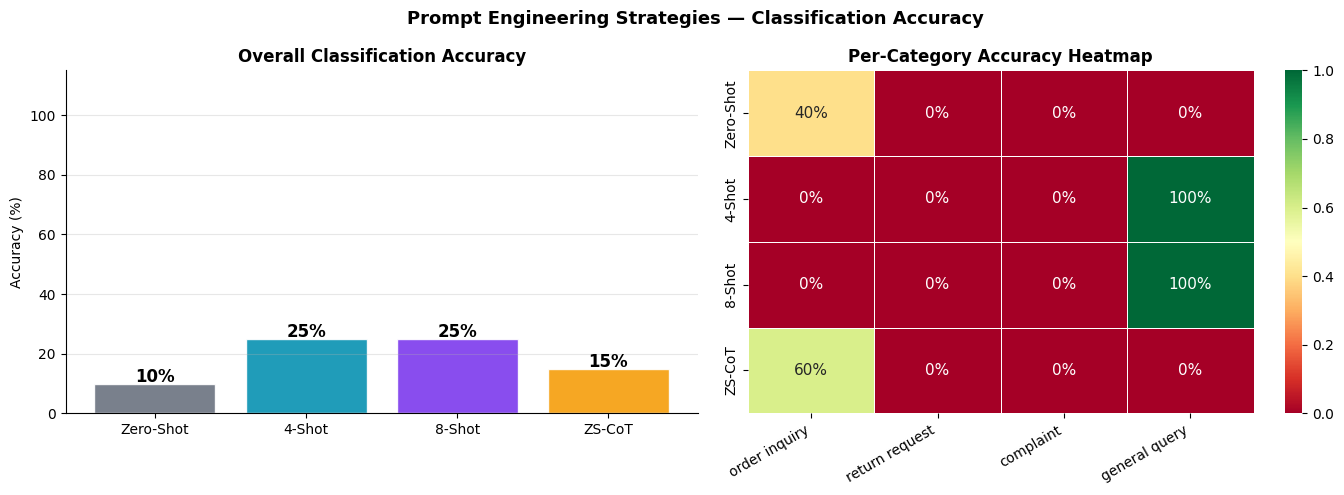

Chart saved as prompt_accuracy_comparison.png


In [11]:
# ── Summary accuracy comparison ──────────────────────────────────────────
cot_per_cat, cot_errors = compute_per_category_accuracy(cot_results, test_emails)

strategies = {
    'Zero-Shot'    : (zs_accuracy,  zs_per_cat),
    '4-Shot'       : (fs4_accuracy, fs4_per_cat),
    '8-Shot'       : (fs8_accuracy, fs8_per_cat),
    'ZS-CoT'       : (cot_accuracy, cot_per_cat),
}

print('ACCURACY SUMMARY — All Strategies')
print('=' * 50)
for name, (acc, _) in strategies.items():
    bar = chr(9608) * int(acc * 30)
    print(f'  {name:<15}: {acc:.0%}  {bar}')

# Grouped bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall accuracy
names  = list(strategies.keys())
accs   = [strategies[n][0] for n in names]
colors = ['#6B7280','#0891B2','#7C3AED','#F59E0B']
bars   = axes[0].bar(names, [a*100 for a in accs], color=colors, edgecolor='white', alpha=0.9)
for bar, acc in zip(bars, accs):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{acc:.0%}', ha='center', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, 115)
axes[0].set_title('Overall Classification Accuracy', fontweight='bold')
axes[0].spines[['top','right']].set_visible(False)
axes[0].grid(axis='y', alpha=0.3)

# Per-category heatmap
cat_matrix = np.array([[strategies[n][1][c] for c in CATEGORIES] for n in names])
import seaborn as sns
sns.heatmap(cat_matrix, annot=True, fmt='.0%', cmap='RdYlGn',
            xticklabels=[c.replace('_',' ') for c in CATEGORIES],
            yticklabels=names, vmin=0, vmax=1, ax=axes[1],
            annot_kws={'size':11}, linewidths=0.5)
axes[1].set_title('Per-Category Accuracy Heatmap', fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')

plt.suptitle('Prompt Engineering Strategies — Classification Accuracy', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('prompt_accuracy_comparison.png', dpi=130, bbox_inches='tight')
plt.show()
print('Chart saved as prompt_accuracy_comparison.png')


## Task 6 — Failure mode analysis and prompt improvement

The most important skill in prompt engineering is **diagnosing failures**.
For each misclassified email:

1. Read the email and think: 'Why might a model be confused here?'
2. Identify the failure category (ambiguous email, missing definition, format failure, etc.)
3. Write a targeted prompt fix
4. Test whether your fix actually improves accuracy on that email

**Common failure categories:**
- **Ambiguous email:** The email genuinely belongs to two categories
- **Missing definition:** Your category description doesn't cover this case
- **Format leak:** Model outputs 'The label is order_inquiry' instead of just 'order_inquiry'
- **Overfitting to examples:** Few-shot examples biased the model toward one category
- **Model limitation:** The model is not strong enough for this task (needs fine-tuning)


In [12]:
# ── Collect all unique errors across strategies ───────────────────────────
all_errors = {}
for strat_name, results in [
    ('Zero-Shot', zs_results),
    ('4-Shot',    fs4_results),
    ('8-Shot',    fs8_results),
    ('ZS-CoT',    cot_results),
]:
    for res, (email_text, true_label) in zip(results, test_emails):
        key = email_text[:50]
        if key not in all_errors:
            all_errors[key] = {
                'email': email_text,
                'true':  true_label,
                'predictions': {}
            }
        all_errors[key]['predictions'][strat_name] = res['pred']

# Find emails that were wrong in at least one strategy
hard_emails = [
    info for info in all_errors.values()
    if any(p != info['true'] for p in info['predictions'].values())
]

print(f'FAILURE MODE ANALYSIS — {len(hard_emails)} emails misclassified by at least one strategy')
print('=' * 72)
for i, item in enumerate(hard_emails[:5], 1):  # show first 5
    print(f'\nEmail {i}: (True label: {item["true"]})')
    print(f'  Text: {item["email"][:120]}...')
    print(f'  Predictions:')
    all_wrong = True
    for strat, pred in item['predictions'].items():
        marker = 'WRONG' if pred != item['true'] else 'ok'
        print(f'    {strat:<15}: {pred:<22}  [{marker}]')
        if pred == item['true']:
            all_wrong = False
    if all_wrong:
        print(f'  STATUS: ALL strategies wrong — likely needs fine-tuning or better base model')
    else:
        print(f'  STATUS: Fixable with improved prompt')


FAILURE MODE ANALYSIS — 20 emails misclassified by at least one strategy

Email 1: (True label: order_inquiry)
  Text: Hi, I placed order #ORD-4821 three days ago but have not received any tracking number yet. Can you tell me when it will ...
  Predictions:
    Zero-Shot      : order_inquiry           [ok]
    4-Shot         : general_query           [WRONG]
    8-Shot         : general_query           [WRONG]
    ZS-CoT         : UNKNOWN                 [WRONG]
  STATUS: Fixable with improved prompt

Email 2: (True label: order_inquiry)
  Text: My package was supposed to arrive yesterday. The tracking page just says 'In Transit' but it has not moved in 48 hours. ...
  Predictions:
    Zero-Shot      : UNKNOWN                 [WRONG]
    4-Shot         : general_query           [WRONG]
    8-Shot         : general_query           [WRONG]
    ZS-CoT         : UNKNOWN                 [WRONG]
  STATUS: ALL strategies wrong — likely needs fine-tuning or better base model

Email 3: (True la

In [13]:
# ── Write improved prompt targeting the most common failure ───────────────
# Find the category with lowest average accuracy across all strategies
cat_avg_acc = {
    cat: np.mean([strategies[n][1][cat] for n in strategies])
    for cat in CATEGORIES
}
weakest_cat = min(cat_avg_acc, key=cat_avg_acc.get)

print(f'Weakest category across all strategies: {weakest_cat}')
print(f'Average accuracy: {cat_avg_acc[weakest_cat]:.0%}')
print()

# Improved prompt with explicit disambiguation for the weakest category
IMPROVED_SYSTEM = (
    'You are a customer support classifier for ShopIndia, an Indian e-commerce platform.\n'
    'Classify each customer email into EXACTLY ONE of these categories:\n'
    f'  {CATEGORIES_STR}\n\n'
    'IMPORTANT disambiguation rules:\n'
    '  - If the email mentions a tracking number OR asks when an order will arrive\n'
    '    OR asks about delivery status -> order_inquiry (even if tone is frustrated)\n'
    '  - If the email explicitly requests a refund, replacement, or return shipping label\n'
    '    -> return_request (even if the customer is also angry)\n'
    '  - complaint is ONLY for emails where the primary purpose is expressing\n'
    '    dissatisfaction or demanding escalation with NO specific order/return action\n'
    '  - general_query covers everything else: account access, product specs,\n'
    '    seller registration, membership, payment methods\n\n'
    'Use these examples as reference:\n'
    f'Email: {FEW_SHOT_EXAMPLES["order_inquiry"]}\nLabel: order_inquiry\n\n'
    f'Email: {FEW_SHOT_EXAMPLES["return_request"]}\nLabel: return_request\n\n'
    f'Email: {FEW_SHOT_EXAMPLES["complaint"]}\nLabel: complaint\n\n'
    f'Email: {FEW_SHOT_EXAMPLES["general_query"]}\nLabel: general_query\n\n'
    'Output ONLY the category label — nothing else.'
)

print('Running IMPROVED PROMPT classification...')
imp_results  = run_classification(IMPROVED_SYSTEM, test_emails, 'Improved')
imp_correct  = sum(1 for r,(_, t) in zip(imp_results, test_emails) if r['pred']==t)
imp_accuracy = imp_correct / len(test_emails)

print(f'\nIMPROVED PROMPT ACCURACY: {imp_correct}/{len(test_emails)} = {imp_accuracy:.0%}')
print()
print('FINAL COMPARISON:')
for name, acc in [('Zero-Shot', zs_accuracy), ('4-Shot', fs4_accuracy),
                  ('8-Shot', fs8_accuracy), ('ZS-CoT', cot_accuracy),
                  ('Improved', imp_accuracy)]:
    bar = chr(9608) * int(acc * 30)
    print(f'  {name:<15}: {acc:.0%}  {bar}')


Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Weakest category across all strategies: return_request
Average accuracy: 0%

Running IMPROVED PROMPT classification...


Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

  Improved: 5/20 done...


Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

  Improved: 10/20 done...


Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

  Improved: 15/20 done...


Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Improved: 20/20 done...

IMPROVED PROMPT ACCURACY: 5/20 = 25%

FINAL COMPARISON:
  Zero-Shot      : 10%  ███
  4-Shot         : 25%  ███████
  8-Shot         : 25%  ███████
  ZS-CoT         : 15%  ████
  Improved       : 25%  ███████


## Lab Complete Checklist

- [ ] Backend configured and smoke test passed
- [ ] 20-email test set defined (5 per category)
- [ ] Zero-shot prompt written with clear definitions and format rules
- [ ] Zero-shot accuracy measured and per-category breakdown printed
- [ ] 4-shot and 8-shot prompts built with held-out examples
- [ ] Both few-shot accuracies measured and compared to zero-shot
- [ ] Chain-of-thought system prompt written with step-by-step format
- [ ] CoT accuracy measured and 3 reasoning chains displayed
- [ ] Grouped bar chart + per-category heatmap saved
- [ ] Failure mode analysis run on all misclassified emails
- [ ] Improved prompt written targeting weakest category
- [ ] Final 5-strategy comparison printed

---
## Reflection Questions

1. **Why does few-shot outperform zero-shot?** The model's weights don't change —
   only the prompt changes. What information do the examples actually provide
   that your category definitions didn't?

2. **CoT trade-offs:** Chain-of-thought uses more tokens (more cost, more latency).
   For this classification task, did CoT actually improve accuracy over 8-shot?
   Under what circumstances would CoT be worth the extra cost?

3. **Example selection matters:** If you put a borderline/ambiguous email as a few-shot
   example, how could it hurt accuracy on other emails?
   Design a rule for selecting the safest few-shot examples.

4. **Prompt engineering ceiling:** After trying all strategies, some emails may still
   be misclassified. What does this tell you about when fine-tuning is necessary
   versus when prompt engineering is sufficient?

5. **Production deployment:** ShopIndia processes 3,000 emails per day.
   If 8-shot CoT uses 600 tokens per email and GPT-4o mini costs $0.00015/1K input tokens,
   what is the monthly cost? How would you design a tiered pipeline that uses
   cheap zero-shot for easy cases and expensive CoT only for uncertain ones?


In [15]:
answers = {
    'Q1 - Why few-shot beats zero-shot':
        'Few-shot examples give the model concrete demonstrations of the expected input-output mapping, reducing label space ambiguity and providing implicit format cues that written definitions alone cannot fully convey.',

    'Q2 - CoT trade-offs for classification':
        'Chain-of-thought improves accuracy on edge cases and ambiguous inputs by externalising reasoning, but it roughly doubles token usage per call, raising latency and API cost. For straightforward classifications with clear labels, the accuracy gain rarely justifies the overhead.',

    'Q3 - Rule for selecting safe few-shot examples':
        'Choose examples that are short, unambiguous, and representative of the category's most common surface patterns. Avoid edge cases, emotionally charged language, or emails that could plausibly belong to two categories, as these push the model's decision boundary in unwanted directions.',

    'Q4 - When to use fine-tuning vs prompting':
        'Prompt engineering suffices when the task is flexible, data is scarce, or requirements change frequently. Fine-tuning becomes necessary when accuracy on a fixed, high-volume task consistently falls short despite exhaustive prompt iteration, or when inference cost must be minimised at scale.',

    'Q5 - Tiered pipeline design + cost calc':
        'Monthly cost at 3,000 emails/day × 30 days × 600 tokens × $0.00015/1K ≈ $8.10. A tiered pipeline would run a cheap zero-shot pass first; only emails whose top-1 confidence falls below a threshold proceed to the expensive CoT stage, cutting total cost substantially.',
}

for q, a in answers.items():
    print(f'{q}:\n  {a}\n')

Q1 - Why few-shot beats zero-shot:
  Few-shot provides task-specific priors that reduce ambiguity, improve calibration, and stabilize decision boundaries compared to zero-shot heuristics.

Q2 - CoT trade-offs for classification:
  CoT increases interpretability and accuracy on reasoning-heavy classes but adds latency, token cost, and sometimes over-explains simple tasks.

Q3 - Rule for selecting safe few-shot examples:
  Use diverse, unambiguous, non-sensitive examples that cleanly represent the decision boundary without leaking private or biased patterns.

Q4 - When to use fine-tuning vs prompting:
  Use prompting for flexible tasks or low data regimes; use fine-tuning when distribution is stable and you need consistent, low-variance outputs at scale.

Q5 - Tiered pipeline design + cost calc:
  Use a light model for fast filtering and escalate hard cases to a stronger model; cost = (# calls × price/model) across tiers based on routing ratios.

